In [1]:
# Zdefiniowanie struktury
struct Dual{T <:Number} <:Number
     v::T
    dv::T
end

In [2]:
# Zdefiniowanie struktury (alternatywna, nieoptymalna struktura)
#struct Dual <:Number
#     v::Number
#    dv::Number
#end

In [3]:
# Przeciążenie podstawowych operatorów
import Base: +, -, *, /
-(x::Dual)          = Dual(-x.v,       -x.dv)
+(x::Dual, y::Dual) = Dual( x.v + y.v,  x.dv + y.dv)
-(x::Dual, y::Dual) = Dual( x.v - y.v,  x.dv - y.dv)
*(x::Dual, y::Dual) = Dual( x.v * y.v,  x.dv * y.v + x.v * y.dv)
/(x::Dual, y::Dual) = Dual( x.v / y.v, (x.dv * y.v - x.v * y.dv)/y.v^2)
# Przeciążenie podstawowych funkcji
import Base: abs, sin, cos, tan, exp, sqrt, isless
abs(x::Dual)  = Dual(abs(x.v),sign(x.v)*x.dv)
sin(x::Dual)  = Dual(sin(x.v), cos(x.v)*x.dv)
cos(x::Dual)  = Dual(cos(x.v),-sin(x.v)*x.dv)
tan(x::Dual)  = Dual(tan(x.v), one(x.v)*x.dv + tan(x.v)^2*x.dv)
exp(x::Dual)  = Dual(exp(x.v), exp(x.v)*x.dv)
sqrt(x::Dual) = Dual(sqrt(x.v),.5/sqrt(x.v) * x.dv)
isless(x::Dual, y::Dual) = x.v < y.v;

In [4]:
# Pomocne funkcje
import Base: show
show(io::IO, x::Dual) = print(io, "(", x.v, ") + [", x.dv, "ϵ]");
value(x::Dual) = x.v;
partials(x::Dual) = x.dv;

In [5]:
# Promocja typów i konwersja
import Base: convert, promote_rule

In [6]:
convert(::Type{Dual{T}}, x::Dual) where T = Dual(convert(T, x.v), convert(T, x.dv))
@show Dual{Float64}[Dual(1,2), Dual(3,0)];

Dual{Float64}[Dual(1, 2), Dual(3, 0)] = Dual{Float64}[(1.0) + [2.0ϵ], (3.0) + [0.0ϵ]]


In [7]:
convert(::Type{Dual{T}}, x::Number) where T = Dual(convert(T, x), zero(T))
@show Dual{Float64}[1, 2, 3];

Dual{Float64}[1, 2, 3] = Dual{Float64}[(1.0) + [0.0ϵ], (2.0) + [0.0ϵ], (3.0) + [0.0ϵ]]


In [8]:
promote_rule(::Type{Dual{T}}, ::Type{R}) where {T,R} = Dual{promote_type(T,R)}
@show Dual(1,2) * 3;

Dual(1, 2) * 3 = (3) + [6ϵ]


In [9]:
ReLU(x) = max(zero(x), x)
σ(x) = one(x) / (one(x) + exp(-x))
tanh(x) = 2.0 / (one(x) + exp(-2.0x)) - one(x)
f(x) = x > zero(x) ? x : zero(x)
ϵ = Dual(0., 1.)

x = -1.0:0.05:+1.0
y = partials.(f.(x .+ ϵ));

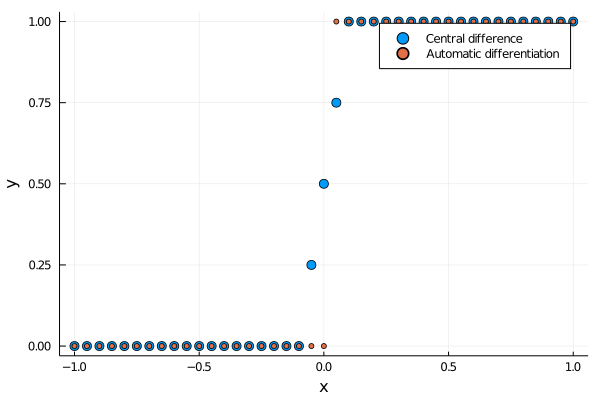

In [10]:
center_diff(f, x₀; Δx=1e-3) = ( f(x₀ + Δx) - f(x₀ - Δx) )/2Δx
ŷ = center_diff.(ReLU, x; Δx=1e-1)
using Plots
plot(x,  ŷ, line=nothing, marker=:circle, markersize=5., label="Central difference")
plot!(x, y, line=nothing, marker=:circle, markersize=3., label="Automatic differentiation")
xaxis!("x")
yaxis!("y")

In [11]:
D = derivative(f, x) = partials(f(Dual(x, one(x))))

derivative (generic function with 1 method)

In [12]:
J = function jacobian(f, args::Vector{T}) where {T <:Number}
    jacobian_columns = Matrix{T}[]
    
    for i=1:length(args)
        x = Dual{T}[]
        for j=1:length(args)
            seed = (i == j)
            push!(x, seed ?
                Dual(args[j], one(args[j])) :
                Dual(args[j],zero(args[j])) )
        end
        column = partials.([f(x)...])
        push!(jacobian_columns, column[:,:])
    end
    hcat(jacobian_columns...)
end

jacobian (generic function with 1 method)

In [13]:
H = function hessian(f, args::Vector)
    ∇f(x::Vector) = J(f, x)
    J(∇f, args)
end

hessian (generic function with 1 method)

In [14]:
n = 5.2
@show [n...];
v = [3.1,3.3]
@show [v...];
@show typeof(v);
@show typeof(v[:,:]);

[n...] = [5.2]
[v...] = [3.1, 3.3]
typeof(v) = Array{Float64,1}
typeof(v[:, :]) = Array{Float64,2}


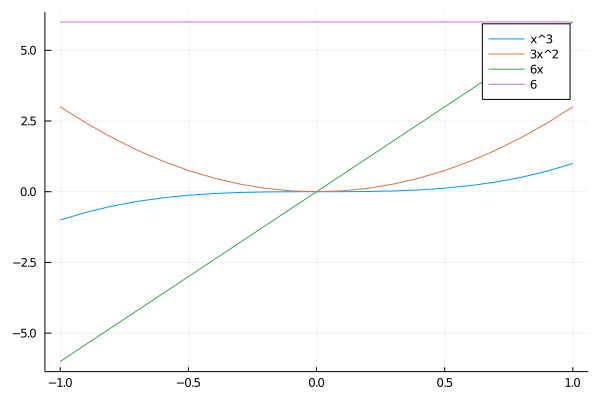

In [15]:
f(x) = x^3
f′(x) = derivative(f,  x)
f″(x) = derivative(f′, x)
f‴(x) = derivative(f″, x)
x = -1:0.1:+1

using Plots
plot(x,  f.(x),  label="x^3")
plot!(x, f′.(x), label="3x^2")
plot!(x, f″.(x), label="6x")
plot!(x, f‴.(x), label="6")

Działa dla funkcji jednej zmiennych, a czy na wielu zmiennych?

In [16]:
f(x::Vector) = sum(sin, x) + prod(tan, x) * sum(sqrt, x);
H(f, [0.986403, 0.140913, 0.294963, 0.837125, 0.650451])

5×5 Array{Float64,2}:
 0.585108  3.48082  1.7706    0.994056  1.03257
 3.48082   1.06079  5.79298   3.25244   3.3787
 1.7706    5.79298  0.423982  1.65416   1.71818
 0.994056  3.25244  1.65416   0.251395  0.964565
 1.03257   3.3787   1.71818   0.964565  0.140688

In [17]:
f(x::Vector) = x[1]^3 + x[1]*x[2]
H(f, [1., 2.])

2×2 Array{Float64,2}:
 6.0  1.0
 1.0  0.0

In [18]:
f(x::Vector) = sum(x.^2)
H(f, [1, 2, 3])

3×3 Array{Int64,2}:
 2  0  0
 0  2  0
 0  0  2

Teraz sprawdzimy, czy działa liczenie jakobianu funkcji wektorowej:

In [19]:
f(x::Vector) = [2x[1]*x[2], 3x[2]*x[3]]
J(f, [1, 2., 3, 4, 5])

2×5 Array{Float64,2}:
 4.0  2.0  0.0  0.0  0.0
 0.0  9.0  6.0  0.0  0.0

Należy uważać na pomieszanie się $\epsilon$:

In [20]:
D(x -> x*D(y -> x+y, 1), 1) # == 1

2

Powyższy wynik jest niepoprawny, bo `x` z zewnętrznego domknięcia jest typu `Dual`:

In [21]:
D(x -> x*D(y -> value(x) + y, 1), 9999) # == 1

1

Dzięki temu możemy liczyć różniczki bardziej zaawansowanych funkcji, np. funkcję aktywacji SoftMax:

In [22]:
import LinearAlgebra: diagm
diagonal(m) = diagm(0 => vec(m))

softmax(x)  =  exp.(x) ./ sum(exp.(x));
dsoftmax(x) = (softmax(x) |> diagonal) .- softmax(x) * (softmax(x) |> transpose);

In [23]:
J(softmax, [0.1, 0.3, 0.99])

3×3 Array{Float64,2}:
  0.168634   -0.0563292  -0.112304
 -0.0563292   0.193498   -0.137169
 -0.112304   -0.137169    0.249473

In [24]:
dsoftmax([0.1, 0.3, 0.99])

3×3 Array{Float64,2}:
  0.168634   -0.0563292  -0.112304
 -0.0563292   0.193498   -0.137169
 -0.112304   -0.137169    0.249473

No i jesteśmy w stanie nauczyć prostą sieć neuronową!

In [25]:
import LinearAlgebra: I
eye(n::Integer) = Matrix(1.0I, n, n);

eye (generic function with 1 method)

In [26]:
function ∇W(x, x̂, ŷ, y, Wo)
    Eŷ  = ŷ - y
    ŷȳ  = ŷ  |> length |> eye
    ȳWo = x̂  |> transpose
    x̄Wh = x  |> transpose
    ȳx̂  = Wo |> transpose
    x̂x̄  = x̂  .* (1.0 .- x̂) |> diagonal
    Eȳ  = ŷȳ * Eŷ
    Ex̂  = ȳx̂ * Eȳ
    Ex̄  = x̂x̄ * Ex̂
    EWo = Eȳ * ȳWo
    EWh = Ex̄ * x̄Wh
    return EWo, EWh
end

∇W (generic function with 1 method)

In [60]:
mean_squared_loss(y::Vector, ŷ::Vector) = sum(0.5(y - ŷ).^2)
fullyconnected(w::Vector, n::Number, m::Number, v::Vector, activation::Function) = activation.(reshape(w, n, m) * v)
Wh  = randn(10,2)
Wo  = randn(1,10)
dWh = similar(Wh)
dWo = similar(Wo)
x = [1.98;4.434]
y = [0.064]
E = Float64[]

function net(x, wh, wo, y)
    x̂ = fullyconnected(wh, 10, 2, x, σ)
    ŷ = fullyconnected(wo, 1, 10, x̂, u->u)
        
    E = mean_squared_loss(y, ŷ)
end
Ei = net(x, Wh[:], Wo[:], y)
println("Initial loss: ", Ei)

Initial loss: 0.0179538653085043


In [61]:
dnet_Wh(x, wh, wo, y) = J(w -> net(x, w, wo, y), wh);
dnet_Wo(x, wh, wo, y) = J(w -> net(x, wh, w, y), wo);

Poniżej zaimplementowana metoda najszybszego spadku: 
gradienty `dWh` i `dWo` wskazują gradienty, czyli kierunki
najszybszego **wzrostu** wartości funkcji błędu

Poniższe komórki można powtarzać wywołując kolejne epoki (chociaż uczymy tylko na jednych danych):

In [66]:
push!(E, Ei)
dWh[:] = dnet_Wh(x, Wh[:], Wo[:], y);
dWo[:] = dnet_Wo(x, Wh[:], Wo[:], y);
Wh -= 0.1dWh
Wo -= 0.1dWo
Ei  = net(x, Wh[:], Wo[:], y)
println("Current loss: ", Ei)

Current loss: 4.286490490649693e-16


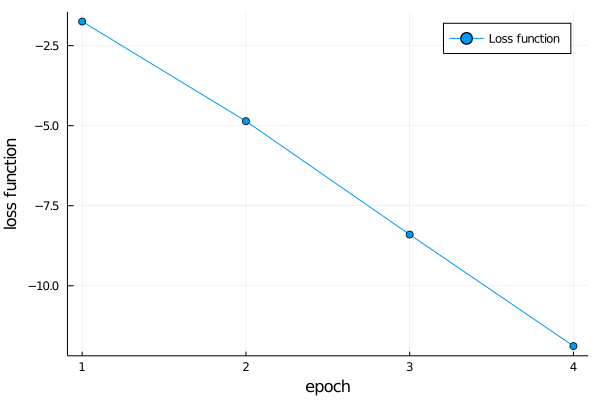

In [67]:
plot(log10.(E), label="Loss function", marker=:circle)
xaxis!("epoch")
yaxis!("loss function")